In [3]:
# Loading Packages
import liana as li
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import os

# Show available methods (from tutorial)
li.mt.show_methods()


,Method Name,Magnitude Score,Specificity Score,Reference
0,CellPhoneDB,lr_means,cellphone_pvals,"Efremova, M., Vento-Tormo, M., Teichmann, S.A...."
0,Connectome,expr_prod,scaled_weight,"Raredon, M.S.B., Yang, J., Garritano, J., Wang..."
0,log2FC,None,lr_logfc,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,NATMI,expr_prod,spec_weight,"Hou, R., Denisenko, E., Ong, H.T., Ramilowski,..."
0,SingleCellSignalR,lrscore,None,"Cabello-Aguilar, S., Alame, M., Kon-Sun-Tack, ..."
0,Rank_Aggregate,magnitude_rank,specificity_rank,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,Geometric Mean,lr_gmeans,gmean_pvals,CellPhoneDBv2's permutation approach applied t...
0,scSeqComm,inter_score,None,"Baruzzo, G., Cesaro, G., Di Camillo, B. 2022. ..."
0,CellChat,lr_probs,cellchat_pvals,"Jin, S., Guerrero-Juarez, C.F., Zhang, L., Cha..."


In [4]:
# File paths
adata_path = "../../Xenopus_to_Human/data/adata_human_mapped_liana_ready.h5ad"
results_dir = "../steady-state_results"
figures_dir = "../steady-state_figures"

os.makedirs(results_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)


In [5]:
# Reload clean to avoid any state issues
adata = sc.read_h5ad(adata_path)

# Preserve raw counts
adata.layers["counts"] = adata.X.copy()

# Normalize and log1p transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Verify normalization
import numpy as np
nonzero_vals = adata.X.data
cell_sums = np.array(adata.X.sum(axis=1)).flatten()
print(f"Non-zero max: {nonzero_vals.max():.4f}")
print(f"Mean cell sum: {cell_sums.mean():.2f}")

# Compute UMAP
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_pcs=30)
sc.tl.umap(adata)
print("UMAP ready. obsm keys:", list(adata.obsm.keys()))


Non-zero max: 7.2910
Mean cell sum: 918.01
UMAP ready. obsm keys: ['X_pca', 'X_umap']


In [ ]:
### Inspection of adata_human_mapped_liana_ready.h5ad ###
# the file does not contain adata.raw 
# adata.X appears to have store log1pnormalized human-mapped expression values
# raw counts are preserved in adata.layers ['counts']
# -> object is suitable for LIANA using use_raw=False.
# The following four cells are not included in the steady-state Ligand-Receptor tutorial!


In [7]:
# 1. Basic structure
print(adata)
print("obs keys:", list(adata.obs.keys()))
print("var keys:", list(adata.var.keys()))
print("uns keys:", list(adata.uns.keys()))
print("obsm keys:", list(adata.obsm.keys()))
print("layers:", list(adata.layers.keys()))


AnnData object with n_obs × n_vars = 29800 × 11119
    obs: 'barcode_base', 'CellBarcode', 'Stages', 'CellType', 'Phenograph', 'Pseudotime_Pltr', 'Differentiation Potential_Pltr', 'Per Stage Louvain', 'CytoTRACE', 'CV', 'CCphase', 'Branch Probabilities Basal', 'Branch Probabilities Goblet', 'Branch Probabilities Ionocytes', 'Branch Probabilities Multiciliated', 'stage_from_file', 'sample'
    var: 'human_symbol'
    uns: 'log1p', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'
obs keys: ['barcode_base', 'CellBarcode', 'Stages', 'CellType', 'Phenograph', 'Pseudotime_Pltr', 'Differentiation Potential_Pltr', 'Per Stage Louvain', 'CytoTRACE', 'CV', 'CCphase', 'Branch Probabilities Basal', 'Branch Probabilities Goblet', 'Branch Probabilities Ionocytes', 'Branch Probabilities Multiciliated', 'stage_from_file', 'sample']
var keys: ['human_symbol']
uns keys: ['log1p', 'pca', 'neighbors', 'umap']
obsm keys: ['X_

In [8]:
# 2. Check that expression matrix is log1p-normalized counts
import numpy as np

print("Has .raw:", adata.raw is not None)
print("X dtype:", adata.X.dtype, "X shape:", adata.X.shape)

# quick range checks
X = adata.X
nonzero = X[X.nonzero()]
print("Nonzero min / max:", float(nonzero.min()), float(nonzero.max()))

cell_sums = np.array(X.sum(axis=1)).flatten()
print("Per-cell counts min / max:", cell_sums.min(), cell_sums.max())
print("Per-cell counts mean:", cell_sums.mean())


Has .raw: False
X dtype: float32 X shape: (29800, 11119)
Nonzero min / max: 1.155710220336914 7.290953159332275
Per-cell counts min / max: 313.85248 2611.4326
Per-cell counts mean: 918.0113


In [9]:
# 3. Cell-type labels and their sizes
print("Unique CellType values:", adata.obs['CellType'].unique())
print(adata.obs['CellType'].value_counts())


Unique CellType values: ['Pluripotent', 'Early epithelial progenitor', 'Multiciliated', 'Basal', 'Goblet', 'Ionocyte']
Categories (6, object): ['Basal', 'Early epithelial progenitor', 'Goblet', 'Ionocyte', 'Multiciliated', 'Pluripotent']
CellType
Early epithelial progenitor    11420
Basal                           7601
Pluripotent                     5541
Multiciliated                   2322
Goblet                          1955
Ionocyte                         961
Name: count, dtype: int64


In [10]:
# 4. Preview a few genes to ensure human symbols
print(adata.var_names[:30])


Index(['A1CF', 'A2M', 'A4GNT', 'AAAS', 'AACS', 'AADAC', 'AADACL4', 'AADAT',
       'AAGAB', 'AAMP', 'AANAT', 'AARS2', 'AARSD1', 'AASDH', 'AASDHPPT',
       'AASS', 'AATF', 'AATK', 'ABAT', 'ABCA1', 'ABCA12', 'ABCA3', 'ABCA4',
       'ABCA5', 'ABCA8', 'ABCB1', 'ABCB6', 'ABCB7', 'ABCB9', 'ABCC1'],
      dtype='object')


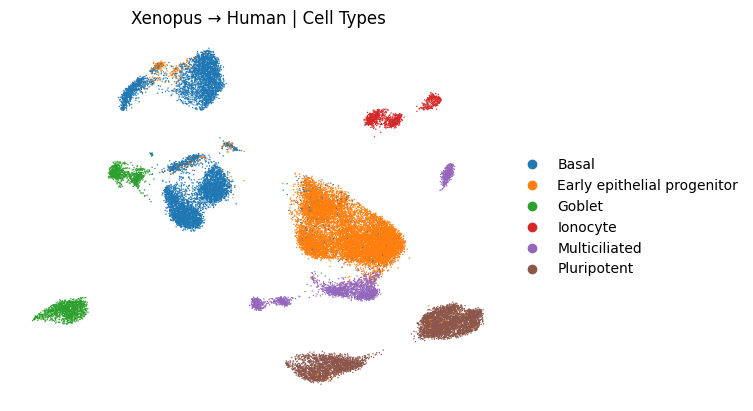

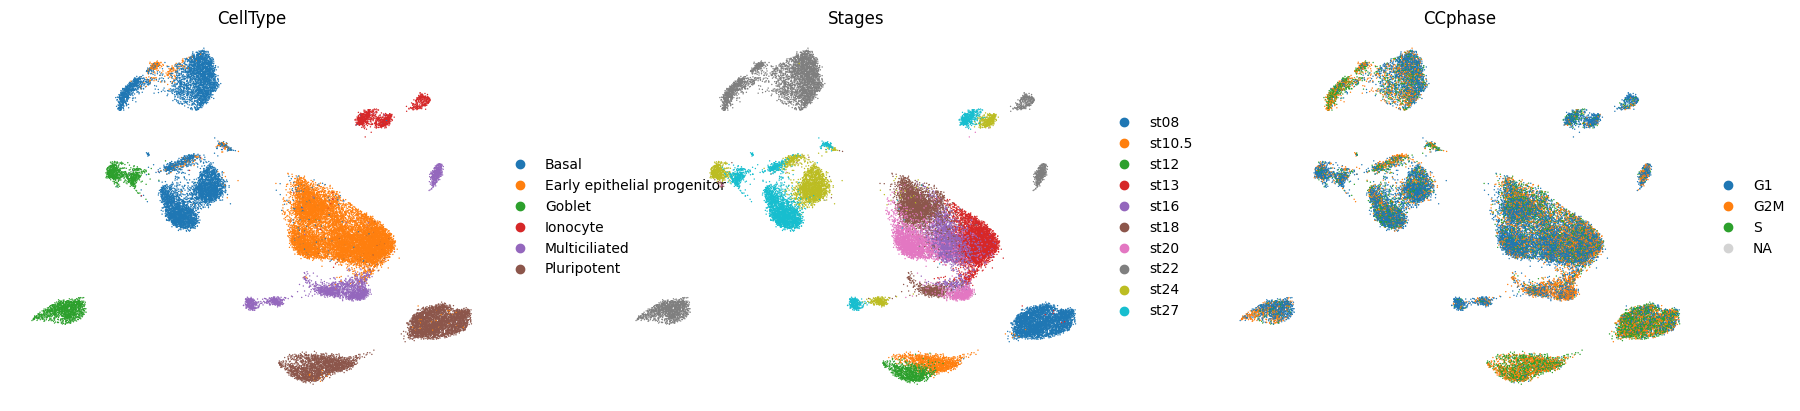

In [11]:
# Coloured by CellType
sc.pl.umap(adata, color='CellType',
           title='Xenopus → Human | Cell Types',
           frameon=False, save='_celltypes.pdf')

# Multi-panel overview
sc.pl.umap(adata, color=['CellType', 'Stages', 'CCphase'],
           frameon=False, ncols=3)


In [12]:
print("Has .raw:", adata.raw is not None)
print("Matrix type (.X):", type(adata.X))
print("Shape:", adata.shape)


Has .raw: False
Matrix type (.X): <class 'scipy.sparse._csr.csr_matrix'>
Shape: (29800, 11119)


In [13]:
# CellPhoneDB method
from liana.method import cellphonedb

cellphonedb(
    adata,
    groupby='CellType',          # your cell identities
    resource_name='consensus',   # human LR resource
    expr_prop=0.1,
    use_raw=False,               # IMPORTANT: use X, since .raw is None
    verbose=True,
    key_added='cpdb_res'
)


Using resource `consensus`.
Using `.X`!
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
557 features of mat are empty, they will be removed.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.53 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 29800 samples and 752 features


100%|██████████| 1000/1000 [00:03<00:00, 254.21it/s]


In [14]:
# Inspect LIANA results table
cpdb_res = adata.uns['cpdb_res']
cpdb_res.to_csv(os.path.join(results_dir, "cpdb_results.csv"), index=False)
print(f"Saved {len(cpdb_res)} interactions")
cpdb_res.head()
cpdb_res.columns

Saved 76 interactions


Index(['ligand', 'ligand_complex', 'ligand_means', 'ligand_props', 'receptor',
       'receptor_complex', 'receptor_means', 'receptor_props', 'source',
       'target', 'lr_means', 'cellphone_pvals'],
      dtype='object')

In [15]:
# Dotplot of CellPhoneDB results
source_labels = ['Pluripotent', 'Early epithelial progenitor', 'Basal']
target_labels = ['Goblet', 'Multiciliated']

dot_cpdb = li.pl.dotplot(
    adata=adata,
    colour='lr_means',
    size='cellphone_pvals',
    inverse_size=True,
    source_labels=source_labels,
    target_labels=target_labels,
    figure_size=(10, 7),
    uns_key='cpdb_res'
)

dot_cpdb.save(os.path.join(figures_dir, "dotplot_cpdb_devfocused.png"))

/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 7 in image.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../steady-state_figures/dotplot_cpdb_devfocused.png


In [16]:
# Tileplo of Ligand vs Receptor stats
tile_cpdb = li.pl.tileplot(
    adata=adata,
    fill='means',
    label='props',
    label_fun=lambda x: f"{x:.2f}",
    top_n=10,
    orderby='cellphone_pvals',
    orderby_ascending=True,
    source_labels=source_labels,
    target_labels=target_labels,
    uns_key='cpdb_res',
    source_title='Ligand',
    target_title='Receptor',
    figure_size=(8, 7)
)

tile_cpdb.save(os.path.join(figures_dir, "tileplot_cpdb.png"))


/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 7 in image.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../steady-state_figures/tileplot_cpdb.png


In [75]:
# Run rank_aggregate
li.mt.rank_aggregate(
    adata,
    groupby='CellType',
    resource_name='consensus',
    expr_prop=0.1,
    use_raw=False,   # again, explicitly use X
    verbose=True
)

ra_res = adata.uns['liana_res']
ra_res.head()




Using resource `consensus`.
Using `.X`!
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
557 features of mat are empty, they will be removed.
Make sure that normalized counts are passed!
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.53 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 29800 samples and 752 features
Assuming that counts were `natural` log-normalized!


/opt/miniconda3/envs/xenopus_liana/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:293: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:296: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.


Running CellPhoneDB


100%|██████████| 1000/1000 [00:03<00:00, 260.85it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
6,Basal,Basal,MDK,NCL,2.949799,0.000,5.916416,0.817977,12.608398,0.220204,0.982474,0.016043,0.001545
13,Basal,Goblet,MDK,NCL,2.027706,0.000,3.554020,0.473492,-4.971462,0.132277,0.977502,0.453758,0.037246
9,Basal,Early epithelial progenitor,MDK,NCL,1.775058,0.000,2.906735,0.379091,-8.516525,0.108186,0.975182,0.579032,0.053142
23,Early epithelial progenitor,Basal,MDK,NCL,2.412407,0.000,0.952426,0.253556,8.330219,0.035448,0.957433,0.491650,0.071662
16,Basal,Ionocyte,MDK,NCL,1.566614,0.144,2.372704,0.301219,-8.711403,0.088310,0.972603,1.000000,0.071662


In [39]:
liana_res = adata.uns['liana_res']
liana_res.to_csv(os.path.join(results_dir, "liana_consensus_results.csv"), index=False)
print(f"Saved {len(liana_res)} consensus interactions")

Saved 76 consensus interactions


In [42]:
# Dotplot
dot_ra = li.pl.dotplot(
    adata,
    colour='magnitude_rank',
    size='specificity_rank',
    inverse_size=True,
    inverse_colour=True,
    source_labels=['Basal', 'Early epithelial progenitor', 'Pluripotent'],
    target_labels=['Goblet', 'Multiciliated'],
    top_n=10,
    orderby='magnitude_rank',
    orderby_ascending=True,  # best (lowest rank) first
    figure_size=(12, 8)
)
dot_ra.save(os.path.join(figures_dir, "dotplot_consensus_top10.png"))


/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 12 x 8 in image.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../steady-state_figures/dotplot_consensus_top10.png


In [ ]:
# Compare top CellPhoneDB vs consensus
cpdb_top = cpdb_res.nsmallest(10, 'cellphone_pvals')[['ligand_complex', 'receptor_complex', 'source', 'target']]
consensus_top = liana_res.nsmallest(10, 'magnitude_rank')[['ligand_complex', 'receptor_complex', 'source', 'target']]

print("Top CellPhoneDB:\n", cpdb_top)
print("\nTop Consensus:\n", consensus_top)
liana_res.to_csv(os.path.join(results_dir, "liana_consensus.csv"), index=False)

# This is not included in the steady-state tutorial


Top CellPhoneDB:
    ligand_complex receptor_complex                       source  \
18            MDK              NCL                        Basal   
7             MDK              NCL                        Basal   
27            MDK              NCL                        Basal   
45            MDK              NCL                        Basal   
58            MDK              NCL                        Basal   
19            MDK              NCL  Early epithelial progenitor   
9             MDK              NCL  Early epithelial progenitor   
36          L1CAM              CD9                     Ionocyte   
54          L1CAM              CD9                     Ionocyte   
43            MDK           TSPAN1                        Basal   

                         target  
18  Early epithelial progenitor  
7                         Basal  
27                       Goblet  
45                     Ionocyte  
58                Multiciliated  
19  Early epithelial progenitor  
9     

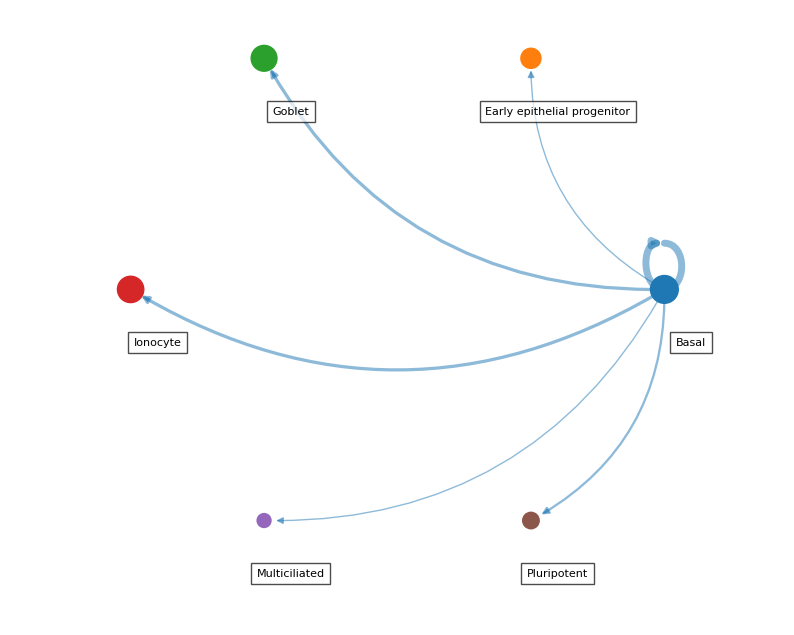

In [23]:
# Circleplot
circle_plot = li.pl.circle_plot(
    adata,
    groupby='CellType',
    score_key='magnitude_rank',
    inverse_score=True,
    source_labels=['Basal'],   # focus Basal outgoing
    pivot_mode='counts',       # count interactions per target
    figure_size=(10, 10)
)

# Save as PNG
circle_plot.figure.savefig(
    os.path.join(figures_dir, "circleplot_basal_counts.png"),
    dpi=300,
)

In [ ]:
# Customize rank_aggregate
# Select 2 methods (tutorial example: logfc + geometric_mean)
from liana.method import logfc, geometric_mean  

methods = [logfc, geometric_mean]  
custom_ra = li.mt.AggregateClass(li.mt.aggregate_meta, methods=methods)  

custom_ra(  
    adata,  
    groupby='CellType',  
    resource_name='consensus',  
    expr_prop=0.1,  
    use_raw=False,  #  X normalization  
    verbose=True,  
    n_perms=None  # skip perms for geometric_mean (tutorial note)  
)  


Using resource `consensus`.
Using `.X`!
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
557 features of mat are empty, they will be removed.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.53 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 29800 samples and 752 features
Assuming that counts were `natural` log-normalized!


/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:293: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:296: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:298: ImplicitModificationWarning: Setting element `.layers['normcounts']` of view, initializing view as actual.


Running log2FC
Running Geometric Mean


In [58]:
adata.uns['liana_res'].head()  

,source,target,ligand_complex,receptor_complex,lr_logfc,lr_gmeans,magnitude_rank
9,Basal,Early epithelial progenitor,MDK,NCL,1.330178,2.789069,0.013158
6,Basal,Basal,MDK,NCL,0.707771,2.757623,0.026316
13,Basal,Goblet,MDK,NCL,0.425408,2.566177,0.039474
16,Basal,Ionocyte,MDK,NCL,0.154442,2.319139,0.052632
19,Basal,Multiciliated,MDK,NCL,0.405010,2.232505,0.065789


/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 12 x 8 in image.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../steady-state_figures/dotplot_custom_rank_aggregate.png


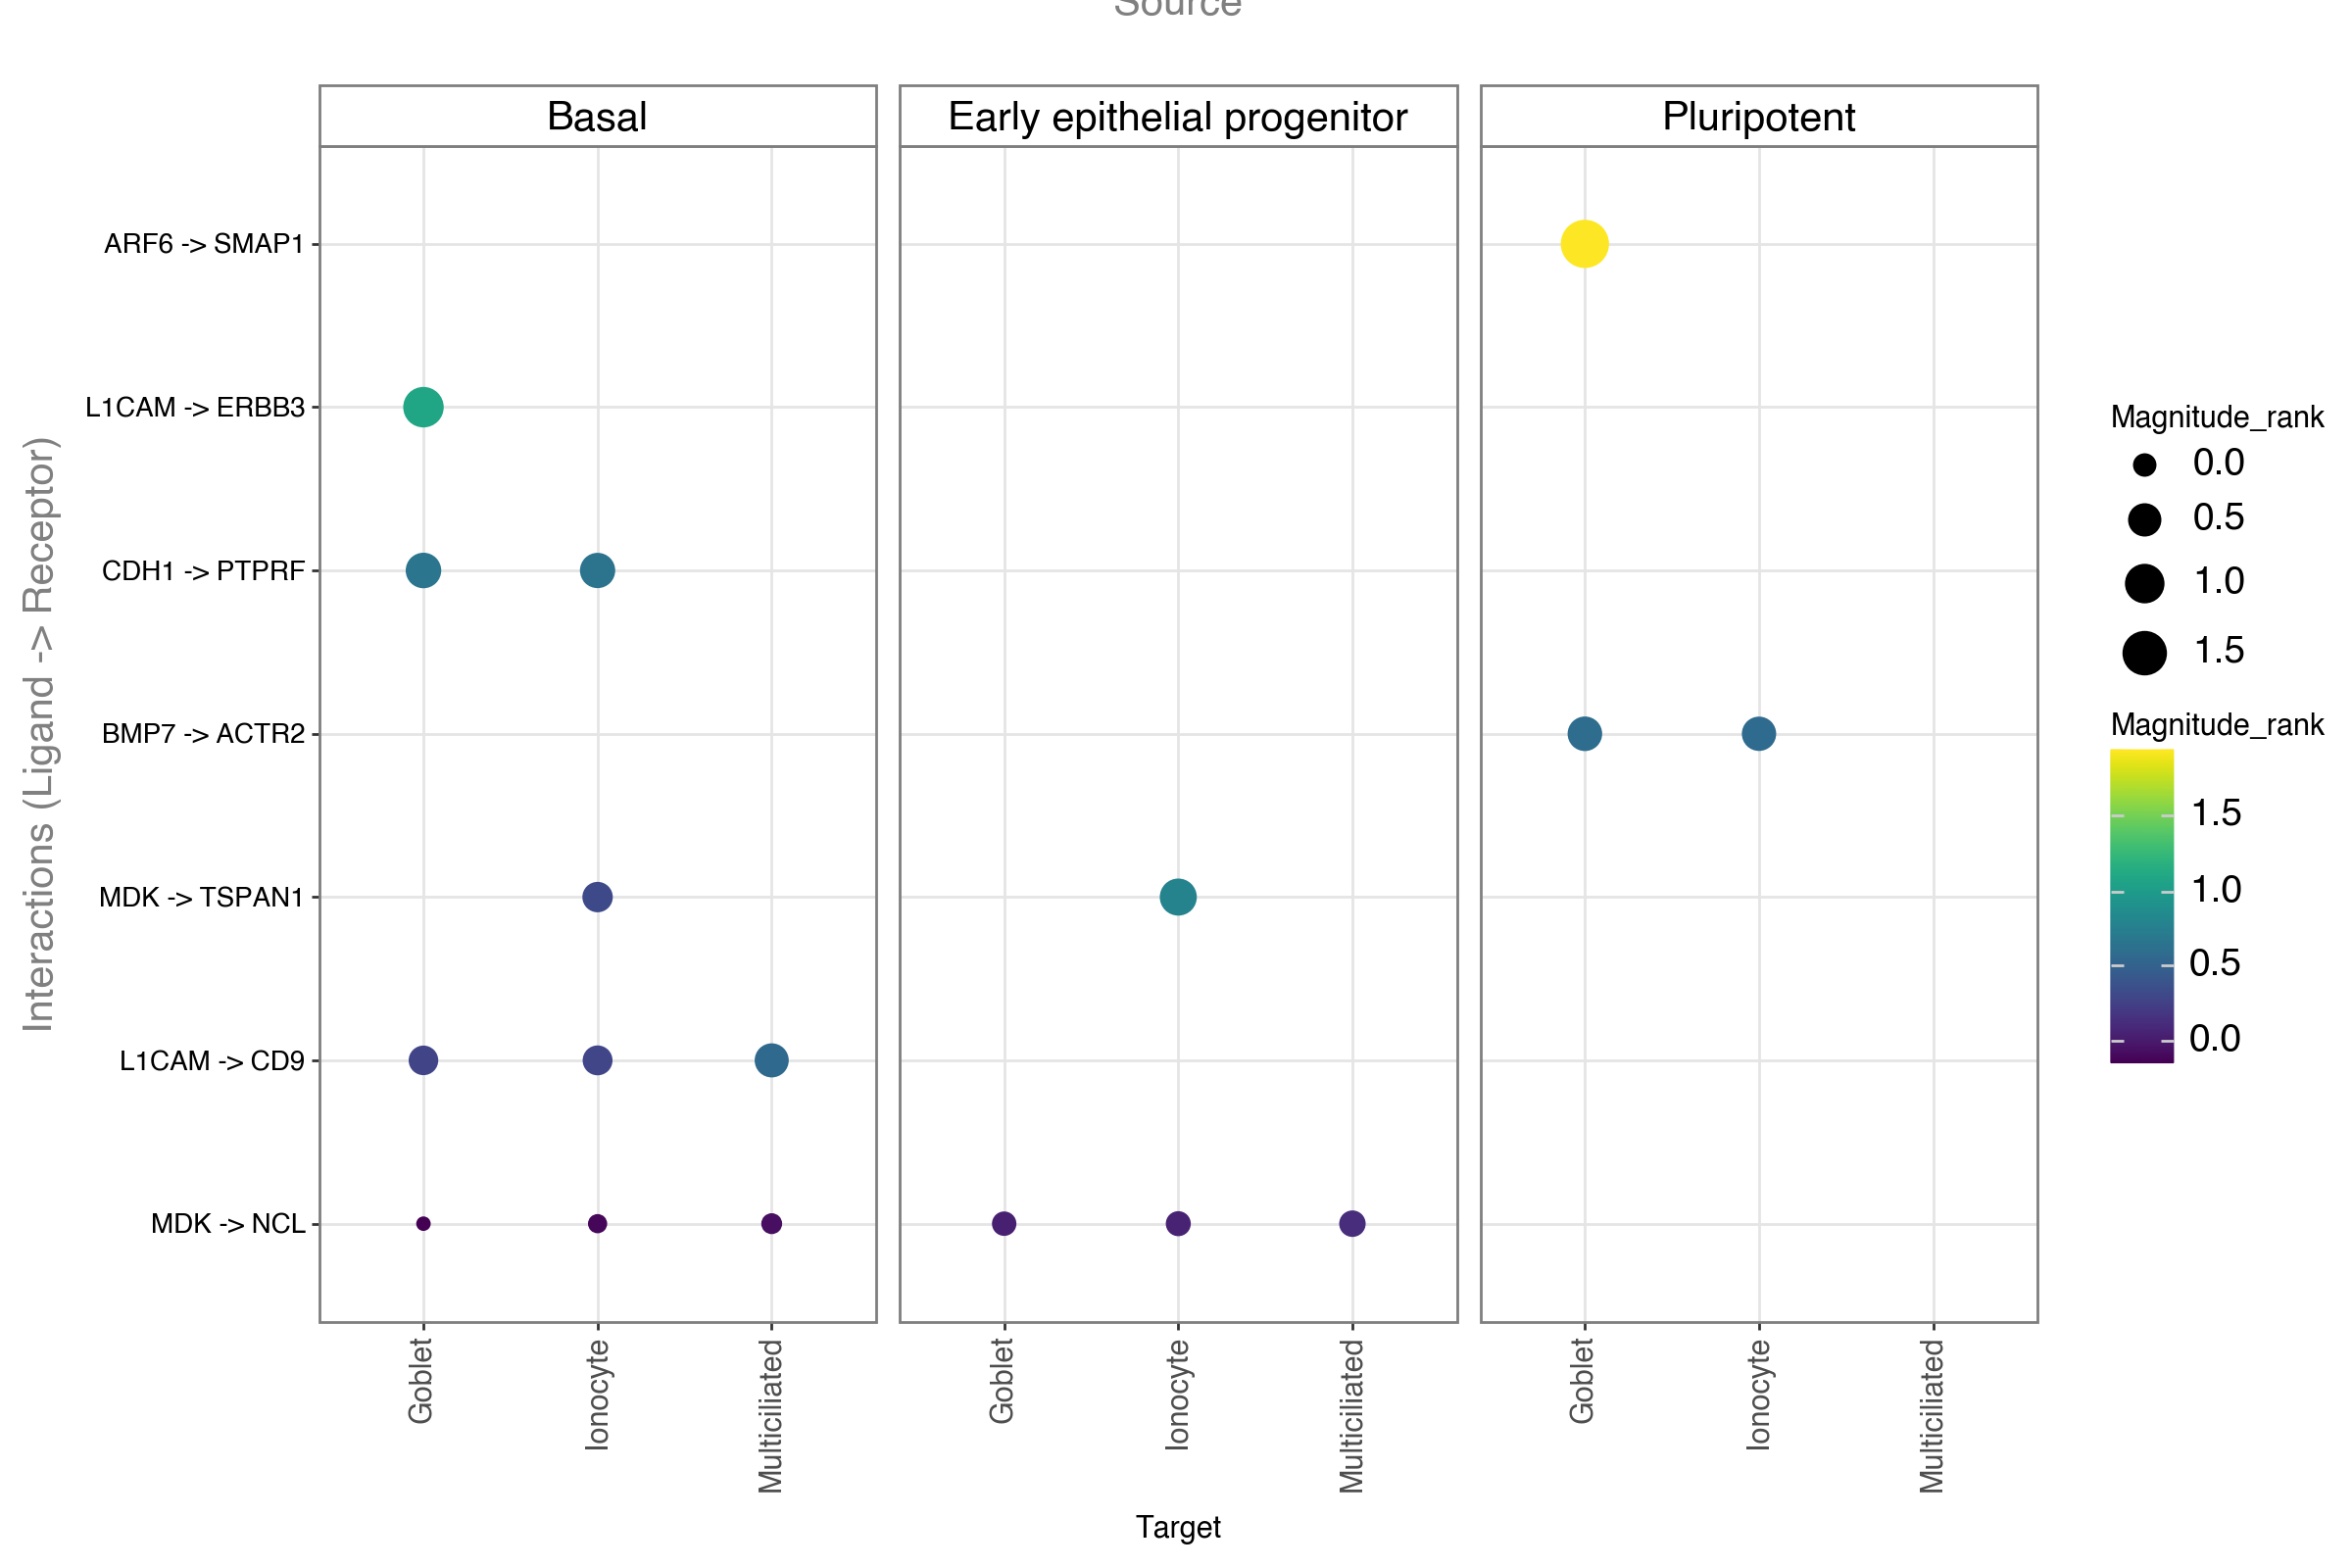

In [25]:
dot_custom = li.pl.dotplot(
    adata,
    colour='magnitude_rank',
    size='magnitude_rank',        # reuse magnitude for size
    inverse_size=True,
    inverse_colour=True,
    source_labels=['Basal', 'Early epithelial progenitor', 'Pluripotent'],
    target_labels=['Goblet', 'Multiciliated', 'Ionocyte'],
    top_n=10,
    orderby='magnitude_rank',
    orderby_ascending=True,
    figure_size=(12, 8)
)

dot_custom.save(os.path.join(figures_dir, "dotplot_custom_rank_aggregate.png"))
dot_custom


In [ ]:
# 1. All interactions in current consensus 
liana_res = adata.uns['liana_res']
print(f"Total interactions: {len(liana_res)}")
print("\nAll unique ligand-receptor pairs:")
print(liana_res[['ligand_complex', 'receptor_complex']].drop_duplicates().head(20))


Total interactions: 76

All unique ligand-receptor pairs:
   ligand_complex receptor_complex
9             MDK              NCL
59          L1CAM              CD9
17            MDK           TSPAN1
7             MDK             SDC2
72           BMP7            ACTR2
20          CALM1             HMMR
14           CDH1            PTPRF
5             LUM            ITGB1
58            HRG            ERBB3
60          L1CAM            ERBB3
38            CGN             OCLN
56           ARF6            SMAP1
0            APOE             SDC2
2           LAMA5             BCAM
4           LAMC1             DAG1
3           LAMA5             DAG1


In [30]:
# 2. By cell type pair (top senders/receivers)
print("Top sender → receiver pairs:")
print(liana_res.groupby(['source', 'target']).size().sort_values(ascending=False).head(10))

print("\nTop ligands overall:")
print(liana_res['ligand_complex'].value_counts().head(10))

print("\nTop receptors overall:")
print(liana_res['receptor_complex'].value_counts().head(10))


Top sender → receiver pairs:
source    target     
Basal     Basal          8
Ionocyte  Goblet         6
Goblet    Goblet         5
Basal     Ionocyte       4
          Goblet         4
Ionocyte  Ionocyte       4
Goblet    Ionocyte       4
          Pluripotent    3
          Basal          3
Basal     Pluripotent    3
dtype: int64

Top ligands overall:
ligand_complex
MDK      32
L1CAM    21
CDH1      6
CALM1     5
BMP7      3
ARF6      2
LAMA5     2
LUM       1
HRG       1
CGN       1
Name: count, dtype: int64

Top receptors overall:
receptor_complex
NCL       24
CD9       18
PTPRF      6
SDC2       5
HMMR       5
TSPAN1     4
ERBB3      4
ACTR2      3
SMAP1      2
DAG1       2
Name: count, dtype: int64


In [31]:
# 3. Full table to CSV (complete list)
liana_res.to_csv(os.path.join(results_dir, "all_liana_interactions.csv"), index=False)
print("Saved ALL interactions to all_liana_interactions.csv")
liana_res.shape


Saved ALL interactions to all_liana_interactions.csv


(76, 7)

In [70]:
import scanpy as sc

# Load the file
adata = sc.read_h5ad("../../Xenopus_to_Human/data/adata_human_mapped_liana_ready.h5ad")

# ── Basic summary ─────────────────────────────────────────────────────────────
print("=== AnnData Summary ===")
print(adata)

# ── First 10 rows of obs (cell metadata) ─────────────────────────────────────
print("\n=== First 10 rows of adata.obs (cell metadata) ===")
print(adata.obs.head(10))

# ── First 10 gene names ───────────────────────────────────────────────────────
print("\n=== First 10 gene names (adata.var_names) ===")
print(adata.var_names[:10].tolist())

# ── All available columns in obs ─────────────────────────────────────────────
print("\n=== All obs columns ===")
print(adata.obs.columns.tolist())

# ── Shape ─────────────────────────────────────────────────────────────────────
print(f"\nShape: {adata.shape[0]} cells × {adata.shape[1]} genes")


=== AnnData Summary ===
AnnData object with n_obs × n_vars = 29800 × 11119
    obs: 'barcode_base', 'CellBarcode', 'Stages', 'CellType', 'Phenograph', 'Pseudotime_Pltr', 'Differentiation Potential_Pltr', 'Per Stage Louvain', 'CytoTRACE', 'CV', 'CCphase', 'Branch Probabilities Basal', 'Branch Probabilities Goblet', 'Branch Probabilities Ionocytes', 'Branch Probabilities Multiciliated', 'stage_from_file', 'sample'
    var: 'human_symbol'

=== First 10 rows of adata.obs (cell metadata) ===
                                                        barcode_base  \
AAACCTGAGACAGAGA-1-GSM4790535_scCapSt08_count.o...  AAACCTGAGACAGAGA   
AAACCTGAGCCTTGAT-1-GSM4790535_scCapSt08_count.o...  AAACCTGAGCCTTGAT   
AAACCTGCAAAGCGGT-1-GSM4790535_scCapSt08_count.o...  AAACCTGCAAAGCGGT   
AAACCTGCAATTCCTT-1-GSM4790535_scCapSt08_count.o...  AAACCTGCAATTCCTT   
AAACCTGCACCAACCG-1-GSM4790535_scCapSt08_count.o...  AAACCTGCACCAACCG   
AAACCTGGTGAGGCTA-1-GSM4790535_scCapSt08_count.o...  AAACCTGGTGAGGCTA   
AAAC

In [72]:
import pandas as pd

# Full cross-tabulation: stage × cell type
crosstab = pd.crosstab(
    adata.obs['Stages'],
    adata.obs['CellType']
)

# Sort stages in developmental order
stage_order = ['st08','st10.5','st12','st13','st16','st18','st20','st22','st24','st27']
crosstab = crosstab.reindex(stage_order)

print("=== Cells per Stage × CellType ===")
print(crosstab.to_string())

print("\n=== Stages with >= 20 cells per cell type ===")
MIN_CELLS = 20
for stage in stage_order:
    row = crosstab.loc[stage]
    valid = row[row >= MIN_CELLS].index.tolist()
    print(f"{stage}: {valid}")

=== Cells per Stage × CellType ===
CellType  Basal  Early epithelial progenitor  Goblet  Ionocyte  Multiciliated  Pluripotent
Stages                                                                                    
st08          0                           31       0         0              0         3377
st10.5        0                            0       0         0              0         1261
st12          0                           19       0         0              0          849
st13          6                         3971       0         0            127           38
st16          2                         2182       0         0            250           12
st18         55                         2771      19         9            517            0
st20         61                         2084       2         3            526            4
st22       3184                          237    1159       239            377            0
st24       2024                           62     434   

In [77]:
# ============================================================
# Stage-specific steady-state LIANA pipeline: st22
# Faithful to tutorial, only change = subset one stage
# ============================================================

import os
import liana as li
from liana.method import cellphonedb

stage = 'st22'
groupby = 'CellType'
stage_key = 'Stages'
min_cells = 5

# -----------------------------
# 1. Subset to stage
# -----------------------------
adata_st22 = adata[adata.obs[stage_key] == stage].copy()

print("Stage:", stage)
print("Total cells:", adata_st22.n_obs)
print("\nCell counts before filtering:")
print(adata_st22.obs[groupby].value_counts())

# -----------------------------
# 2. Keep cell types with >= 5 cells
# -----------------------------
cell_counts = adata_st22.obs[groupby].value_counts()
valid_celltypes = cell_counts[cell_counts >= min_cells].index.tolist()

print("\nValid cell types (>= 5 cells):")
print(valid_celltypes)

if len(valid_celltypes) < 2:
    raise ValueError(f"{stage} has fewer than 2 valid cell types after filtering.")

adata_st22 = adata_st22[
    adata_st22.obs[groupby].isin(valid_celltypes)
].copy()

print("\nCell counts after filtering:")
print(adata_st22.obs[groupby].value_counts())

# For the first run, use all valid cell types
source_labels = valid_celltypes
target_labels = valid_celltypes

# ============================================================
# A. CellPhoneDB
# ============================================================
cellphonedb(
    adata_st22,
    groupby=groupby,
    resource_name='consensus',
    expr_prop=0.1,
    use_raw=False,   # because your object has no .raw
    verbose=True,
    key_added='cpdb_res'
)

cpdb_res_st22 = adata_st22.uns['cpdb_res'].copy()
cpdb_res_st22['stage'] = stage

cpdb_csv = os.path.join(results_dir, f"cpdb_res_{stage}.csv")
cpdb_res_st22.to_csv(cpdb_csv, index=False)

print(f"\nSaved CPDB results: {cpdb_csv}")
print("CPDB result shape:", cpdb_res_st22.shape)
print(cpdb_res_st22.head())

# ============================================================
# B. CPDB dotplot + tileplot (only if non-empty)
# ============================================================
if cpdb_res_st22.empty:
    print(f"No CPDB interactions for {stage}; skipping CPDB dotplot and tileplot.")
else:
    dot_cpdb_st22 = li.pl.dotplot(
        adata=adata_st22,
        colour='lr_means',
        size='cellphone_pvals',
        inverse_size=True,
        source_labels=source_labels,
        target_labels=target_labels,
        figure_size=(8, 7),
        filter_fun=lambda x: x['cellphone_pvals'] <= 0.05,
        uns_key='cpdb_res'
    )

    dot_cpdb_path = os.path.join(figures_dir, f"dotplot_cpdb_{stage}.png")
    dot_cpdb_st22.save(dot_cpdb_path)
    print(f"Saved CPDB dotplot: {dot_cpdb_path}")

    tile_cpdb_st22 = li.pl.tileplot(
        adata=adata_st22,
        fill='means',
        label='props',
        label_fun=lambda x: f"{x:.2f}",
        top_n=10,
        orderby='cellphone_pvals',
        orderby_ascending=True,
        source_labels=source_labels,
        target_labels=target_labels,
        uns_key='cpdb_res',
        source_title='Ligand',
        target_title='Receptor',
        figure_size=(8, 7)
    )

    tile_cpdb_path = os.path.join(figures_dir, f"tileplot_cpdb_{stage}.png")
    tile_cpdb_st22.save(tile_cpdb_path)
    print(f"Saved CPDB tileplot: {tile_cpdb_path}")

# ============================================================
# C. Rank aggregate
# ============================================================
try:
    li.mt.rank_aggregate(
        adata_st22,
        groupby=groupby,
        resource_name='consensus',
        expr_prop=0.1,
        use_raw=False,   # because your object has no .raw
        verbose=True
    )

    liana_res_st22 = adata_st22.uns['liana_res'].copy()

    if liana_res_st22.empty:
        print(f"No consensus interactions for {stage}; skipping consensus plot.")
    else:
        liana_res_st22['stage'] = stage
        liana_csv = os.path.join(results_dir, f"liana_res_{stage}.csv")
        liana_res_st22.to_csv(liana_csv, index=False)

        print(f"\nSaved consensus results: {liana_csv}")
        print("Consensus result shape:", liana_res_st22.shape)
        print(liana_res_st22.head())

        dot_consensus_st22 = li.pl.dotplot(
            adata=adata_st22,
            colour='magnitude_rank',
            size='specificity_rank',
            inverse_size=True,
            inverse_colour=True,
            source_labels=source_labels,
            target_labels=target_labels,
            top_n=10,
            orderby='magnitude_rank',
            orderby_ascending=True,
            figure_size=(8, 7)
        )

        dot_consensus_path = os.path.join(figures_dir, f"dotplot_consensus_{stage}.png")
        dot_consensus_st22.save(dot_consensus_path)
        print(f"Saved consensus dotplot: {dot_consensus_path}")

except Exception as e:
    print(f"No consensus interactions for {stage} under tutorial settings: {e}")

Using resource `consensus`.
Using `.X`!
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
1109 features of mat are empty, they will be removed.
Make sure that normalized counts are passed!


Stage: st22
Total cells: 5196

Cell counts before filtering:
CellType
Basal                          3184
Goblet                         1159
Multiciliated                   377
Ionocyte                        239
Early epithelial progenitor     237
Name: count, dtype: int64

Valid cell types (>= 5 cells):
['Basal', 'Goblet', 'Multiciliated', 'Ionocyte', 'Early epithelial progenitor']

Cell counts after filtering:
CellType
Basal                          3184
Goblet                         1159
Multiciliated                   377
Ionocyte                        239
Early epithelial progenitor     237
Name: count, dtype: int64


/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.59 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 5196 samples and 626 features


100%|██████████| 1000/1000 [00:00<00:00, 1041.89it/s]
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 7 in image.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./stage_liana_figures/dotplot_cpdb_st22.png


...

Saved CPDB dotplot: ./stage_liana_figures/dotplot_cpdb_st22.png
Saved CPDB tileplot: ./stage_liana_figures/tileplot_cpdb_st22.png


Using `.X`!
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
1109 features of mat are empty, they will be removed.
Make sure that normalized counts are passed!
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.59 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 5196 samples and 626 features
Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


/opt/miniconda3/envs/xenopus_liana/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:293: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:296: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
100%|██████████| 1000/1000 [00:00<00:00, 1112.96it/s]
/opt/miniconda3/envs/xenopus_liana/lib/python3.11/site-packages/liana/plotting/_c

Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR

Saved consensus results: ./stage_liana_results/liana_res_st22.csv
Consensus result shape: (86, 14)
                         source                       target ligand_complex  \
7                         Basal                        Basal            MDK   
13                        Basal  Early epithelial progenitor            MDK   
29  Early epithelial progenitor                        Basal            MDK   
18                        Basal                       Goblet            MDK   
32  Early epithelial progenitor  Early epithelial progenitor            MDK   

   receptor_complex  lr_means  cellphone_pvals  expr_prod  scaled_weight  \
7               NCL  3.882711            0.000   9.492027       0.359724   
13              NCL  3.114321            0.142   7.156451       0.153110   
29              NCL  3.409739            0.000   3.583997       0.015442   
18              NCL  2.372494            1.000 